# The FOMC Vol Crush — a quantitative teardown 🔬
### Decision-day Welch/HAC splits · a 20-seed random-calendar placebo · the [−5..+3] event anatomy · the realized-vs-implied cross-check · the press-conference-era contrast · an honest SVXY capture test · a 20-seed synthetic null

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Retail_capture%3F: Mixed](https://img.shields.io/badge/Retail_capture%3F-Mixed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — **implied vol collapses into the scheduled FOMC decision close** — is one of the rare folklore claims with a stated mechanism (event-premium expiry), an academic anchor (Amengual-Xiu 2018) and a hard calendar. The job here is to measure it honestly, then ask the only question that pays: *is any of it tradable?*

> ⚠️ **Data note.** ^VIX daily OHLC + SPY raw OHLC (1994→2026) + SVXY adjusted closes (2011→2026), yfinance, cached; **261 hardcoded scheduled decision dates** from the Fed calendar archive (scheduled only — emergency actions are surprises, excluded by construction; the pre-empted 2020-03-18 date is kept, named quirk). No survivorship on the Signal axis (indices); **SVXY's survivor status is named on the third axis** (XIV died 2018-02-05). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprints `e876dcb8d22b` / `d0ce62443ce7` / `a876bb11537c`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from fomc_vol_crush import data, strategy as st

FOMC = data.fomc_calendar()
HAVE_REAL = data.have_real()
if HAVE_REAL:
    VIX, SPY, SVXY = data.load_real()
    DF = st.day_frame(VIX, SPY, FOMC)
else:
    VIX = SPY = SVXY = DF = None
print("real cache present:", HAVE_REAL, "| scheduled FOMC decisions:", len(FOMC),
      "| tape days:", (0 if DF is None else len(DF)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '1994-01-03', 'end': '2026-06-30', 'n_fomc': 261, 'n_rest': 7916, 'cal_lo': '1994-02-04', 'cal_hi': '2026-06-17', 'fomc_pts': -0.415, 'rest_pts': 0.014, 'gap_pts': -0.429, 'fomc_logpct': -1.97, 'rest_logpct': 0.07, 'welch_pts': -3.51, 'welch_log': -3.94, 'nw_t': -3.47, 'hit': 172, 'hit_pct': 65.9, 'wilson': (60.0, 71.4), 'placebo_p': 5e-05, 'placebo_mean': 0.016, 'placebo_sd': 0.105, 'placebo_draws': 20000, 'event': {-5: (-0.05, -0.53), -4: (-0.079, -0.79), -3: (-0.014, -0.18), -2: (0.301, 2.27), -1: (0.05, 0.35), 0: (-0.415, -3.45), 1: (0.02, 0.1), 2: (-0.105, -1.22), 3: (0.12, 0.82)}, 'runup_pts': 0.209, 'runup_t': 0.9, 'spy_fomc': 1.557, 'spy_rest': 1.296, 'spy_t': 4.04, 'era_early': -0.549, 'era_early_n': 139, 'era_early_t': -4.81, 'era_late': -0.262, 'era_late_n': 122, 'era_late_t': -1.21, 'era_diff_t': 1.15, 'sv_gross': 58.9, 'sv_net5': 48.9, 'sv_net10': 38.9, 'sv_rest': 10.9, 'sv_t': 1.58, 'sv_n': 118, 'sv_hit': 61.9, 'sv_worst': -10.5, 'sv_ann5': 3.91, 'sv_ann10': 3.11, 'sv_post_gross': 14.7, 'sv_post_t': 0.24, 'sv_post_n': 67, 'syn_null_mean': -0.04, 'syn_null_sd': 1.04, 'syn_null_fire': 0, 'syn_planted_t': -15.67, 'fp_vix': 'e876dcb8d22b', 'fp_spy': 'd0ce62443ce7', 'fp_svxy': 'a876bb11537c'}


real cache present: True | scheduled FOMC decisions: 261 | tape days: 8177


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `REAL` | decision-day ΔVIX **-0.415 pts (-1.97%)** vs +0.014: Welch **t = -3.51** (pts) / **-3.94** (log), NW **t = -3.47**, hit 65.9% (Wilson [60.0%, 71.4%]), placebo **p = 0.00005** |
| **Tradability** | `MIRAGE` | spot ^VIX untradable; SVXY echo t = 1.58 full-sample, **t = 0.24** post-2018, worst day -10.5% |
| **Retail capture?** | `MIXED` | +49 bps net/event in sample, uncertifiable; ≈ 0 since the −0.5× de-leverage |

> 💡 In plain words: the crush is real physics on the tape; the tradable echo is a rumor the statistics decline to confirm.

## 1 · The claim, steelmanned

Let $\Delta v_t$ be the daily ^VIX close-to-close change and $D_t \in \{0,1\}$ the scheduled-decision-day flag (known *ex ante* — the calendar is published years ahead). The statement (14:00/14:15 ET) predates the ^VIX close (16:15 ET), so the decision-day bar contains the resolution. The claims:

- **H₁ (crush).** $E[\Delta v_t \mid D_t=1] \ll E[\Delta v_t \mid D_t=0]$ — large, systematic, not a calendar coincidence.
- **H₂ (anatomy).** A run-up before ($\Delta v > 0$ pre-meeting) and no bounce-back after (the premium is extinguished, not displaced).
- **H₃ (resolution, not calm).** Realized SPY range on decision days is *not* below average — implied falls while realized is loud.
- **H₄ (capture).** A retail short-vol expression (SVXY, decision day only) banks it net of costs.

We find **H₁ strongly supported**, **H₂ half-supported** (crush sticks; the run-up is faint, t = 0.90), **H₃ supported** (range t = +4.04), **H₄ not certified** (t = 1.58; t = 0.24 post-2018).

## 2 · So what? — inference design

Decision days are **single, non-overlapping events**, so the planned primary is a **Welch t** on the group split (points and logs — logs tame the level dependence of vol-point moves). Because daily ΔVIX is serially correlated, we cross-check with a **Newey-West (5-lag) t** on the dummy regression $\Delta v_t = a + b D_t$ — the slope *is* the mean gap. The hit rate carries a **Wilson interval** (no conditional claim without uncertainty), the placebo draws 261 random non-FOMC days **20,000 times (20 seeds × 1,000)**, and the era split (2011-04-27, first post-meeting press conference) is justified *ex ante*, not snooped — and tested as a **difference**, not eyeballed.

## 3 · How we'd know — the protocol

- **Calendar.** 261 scheduled decisions 1994-02-04 → 2026-06-17, hardcoded (Fed calendar archive; scheduled only). All 261 sit on the tape.
- **Tape.** ^VIX OHLC + SPY raw OHLC 1994-01-03 → 2026-06-30; SVXY total-return closes from 2011-10 inception. As-of 2026-06-30 (last complete month).
- **Headline.** Welch t (pts + log) + NW(5) t + Wilson hit rate + 20-seed placebo.
- **Anatomy.** Event window [−5..+3], per-offset Welch t vs far days; cumulative run-up per meeting, one-sample t.
- **Cross-check.** SPY (H−L)/prev-close split on the same days.
- **Execution (third axis).** Enter SVXY at the prior close (calendar public — zero look-ahead), exit the decision close; 2 × one-way cost × NAV per event; long-only, no borrow.
- **Control.** Synthetic OU vol index, planted crush knob; the null must not fire across 20 seeds.

## 4 · The teardown

### 4a · The headline split and its placebo

Welch t on ΔVIX (points and logs), NW t on the dummy regression, and the random-calendar null. In the notebook we run a lighter placebo (4 seeds × 500 draws) and quote the canonical 20,000-draw p from `results.md`.

FOMC-day ΔVIX -0.415 pts (-1.97%)  vs  other +0.014 pts (+0.07%)
Welch t = -3.51 (pts) / -3.94 (log)   NW(5) t = -3.47
hit 172/261 = 65.9%  Wilson [60.0%, 71.4%]


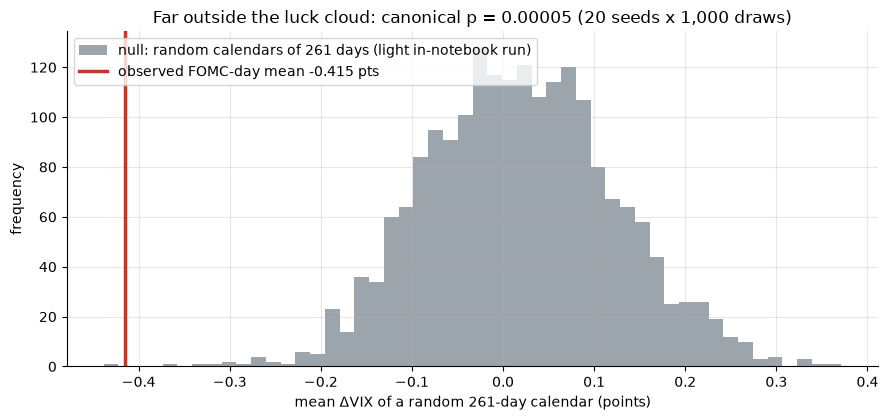

canonical placebo (results.md): mean +0.016, sd 0.105, p = 0.00005


In [2]:
if HAVE_REAL:
    s = st.decision_day_stats(DF)
    print(f"FOMC-day ΔVIX {s['fomc_pts']:+.3f} pts ({s['fomc_logpct']:+.2f}%)  vs  "
          f"other {s['rest_pts']:+.3f} pts ({s['rest_logpct']:+.2f}%)")
    print(f"Welch t = {s['welch_t_pts']:+.2f} (pts) / {s['welch_t_log']:+.2f} (log)   "
          f"NW(5) t = {s['nw_t_pts']:+.2f}")
    print(f"hit {s['hit_down']}/{s['n_fomc']} = {s['hit_rate']*100:.1f}%  "
          f"Wilson [{s['hit_lo']*100:.1f}%, {s['hit_hi']*100:.1f}%]")
    pl = st.placebo_pvalue(DF, n_draws_per_seed=500, n_seeds=4)
    obs, draws = pl['obs'], pl['draws']
else:
    obs = R['fomc_pts']
    rng = np.random.default_rng(637)
    draws = rng.normal(R['placebo_mean'], R['placebo_sd'], 2000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=50, color=GREY, alpha=.85,
        label='null: random calendars of 261 days (light in-notebook run)')
ax.axvline(obs, c=RED, lw=2.5, label=f'observed FOMC-day mean {obs:+.3f} pts')
ax.set_xlabel('mean ΔVIX of a random 261-day calendar (points)')
ax.set_ylabel('frequency')
ax.set_title(f"Far outside the luck cloud: canonical p = {R['placebo_p']:.5f} "
             '(20 seeds x 1,000 draws)')
ax.legend(); plt.tight_layout(); plt.show()
print(f"canonical placebo (results.md): mean {R['placebo_mean']:+.3f}, "
      f"sd {R['placebo_sd']:.3f}, p = {R['placebo_p']:.5f}")

> 💡 In plain words: the observed **-0.415 pts** sits about four placebo-sigmas below the null's center (+0.016 ± 0.105); **p = 0.00005**. With Welch t = **-3.94** (log) and NW t = **-3.47**, H₁ clears the desk bar three separate ways.

### 4b · Anatomy — run-up, crush, persistence

Per-offset means with Welch t vs far-from-meeting days; the run-up is tested as a **cumulative per-meeting** quantity (one-sample t across 261 meetings).

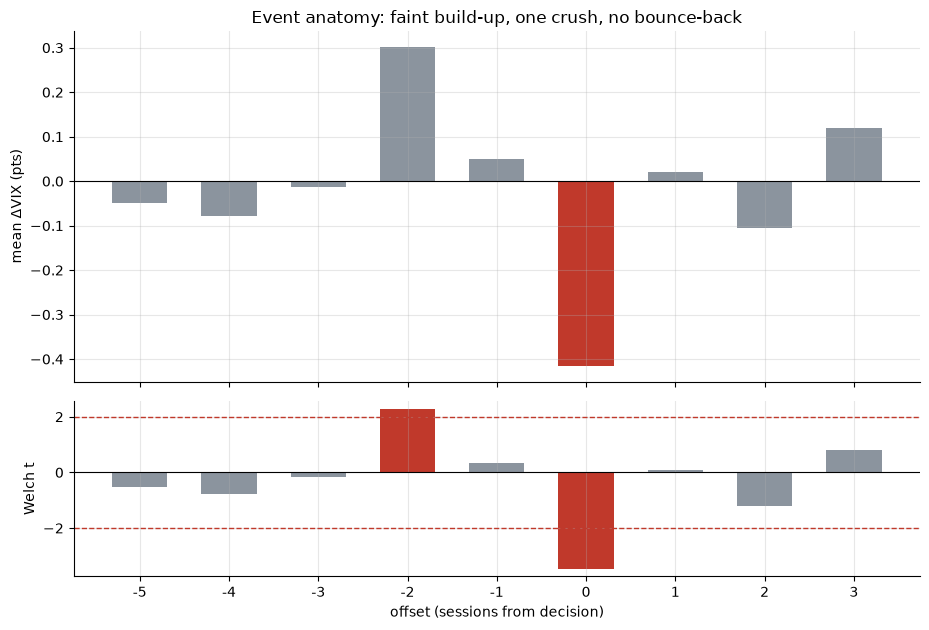

cumulative run-up [-5..-1]: +0.209 pts/meeting (t = +0.90)


In [3]:
if HAVE_REAL:
    ev = st.event_study(DF, FOMC)
    ks = list(ev.index); ms = list(ev['mean_pts']); ts = list(ev['welch_t'])
    ru = st.runup_stats(DF, FOMC)
    ru_m, ru_t = ru['mean_runup_pts'], ru['t']
else:
    ks = sorted(R['event']); ms = [R['event'][k][0] for k in ks]
    ts = [R['event'][k][1] for k in ks]; ru_m, ru_t = R['runup_pts'], R['runup_t']
fig, (a1, a2) = plt.subplots(2, 1, figsize=(9.4, 6.4), sharex=True,
                             gridspec_kw={'height_ratios': [2, 1]})
cols = [RED if k==0 else GREY for k in ks]
a1.bar([str(k) for k in ks], ms, color=cols, width=.62)
a1.axhline(0, c='k', lw=.8); a1.set_ylabel('mean ΔVIX (pts)')
a1.set_title('Event anatomy: faint build-up, one crush, no bounce-back')
a2.bar([str(k) for k in ks], ts, color=[RED if abs(t)>=2 else GREY for t in ts], width=.62)
a2.axhline(0, c='k', lw=.8)
a2.axhline(-2, ls='--', c=RED, lw=1); a2.axhline(2, ls='--', c=RED, lw=1)
a2.set_ylabel('Welch t'); a2.set_xlabel('offset (sessions from decision)')
plt.tight_layout(); plt.show()
print(f'cumulative run-up [-5..-1]: {ru_m:+.3f} pts/meeting (t = {ru_t:+.2f})')

> 💡 In plain words: only two bars matter — day 0 (**-0.415**, t = -3.45) and, mildly, day −2 (**+0.301**, t = +2.27). The cumulative pre-meeting run-up is **+0.21 pts at t = +0.90** — folklore says the VIX "always ramps into the Fed"; the tape says *barely, if at all*. And day +1 is **+0.020** (t = +0.10): the crush is a level reset, not a dip that mean-reverts — exactly what premium-expiry predicts and what a liquidity glitch would not.

### 4c · Resolution, not calm — the realized cross-check

If decision days were simply *quiet*, a VIX drop would be trivial. They are the opposite:

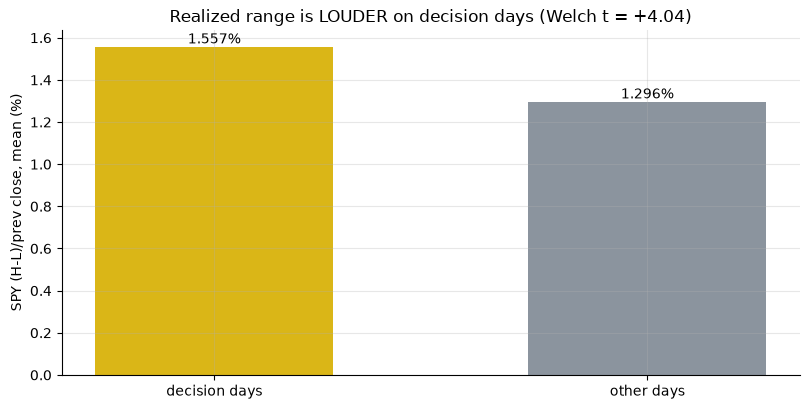

SPY range: FOMC 1.557%  vs other 1.296%   Welch t = +4.04


In [4]:
if HAVE_REAL:
    rg = st.spy_range_stats(DF)
    a, b, t = rg['fomc_range_pct'], rg['rest_range_pct'], rg['welch_t']
else:
    a, b, t = R['spy_fomc'], R['spy_rest'], R['spy_t']
fig, ax = plt.subplots(figsize=(8.2, 4.2))
ax.bar(['decision days','other days'], [a, b], color=[AMBER, GREY], width=.55)
for i,v in enumerate([a, b]): ax.annotate(f'{v:.3f}%',(i,v),ha='center',va='bottom')
ax.set_ylabel('SPY (H-L)/prev close, mean (%)')
ax.set_title(f'Realized range is LOUDER on decision days (Welch t = {t:+.2f})')
plt.tight_layout(); plt.show()
print(f'SPY range: FOMC {a:.3f}%  vs other {b:.3f}%   Welch t = {t:+.2f}')

> 💡 In plain words: the S&P moves **1.56%** high-to-low on decision days vs **1.30%** otherwise (t = +4.04) — among the louder days on the calendar — while implied vol falls ~2% into the same close. Implied prices the *future*: once the statement is out, tomorrow has less uncertainty in it, however wild today was. H₃ holds; the crush is resolution, not calm.

### 4d · The era contrast — justified split, tested as a difference

Split at **2011-04-27** (the first post-meeting press conference — the structural change in decision communication; chosen ex ante, not snooped).

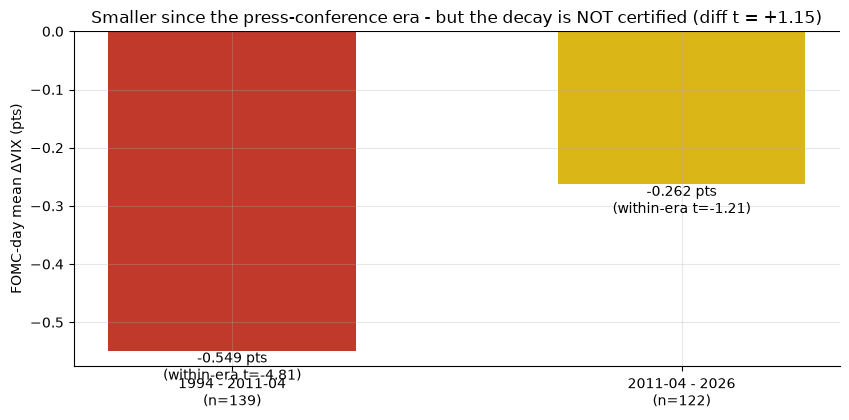

early -0.549 (t=-4.81)  late -0.262 (t=-1.21)  diff t = +1.15


In [5]:
if HAVE_REAL:
    ec = st.era_contrast(DF, data.PRESSER_SPLIT)
    e, l = ec['early_pts'], ec['late_pts']
    et, lt, dt = ec['welch_t_early'], ec['welch_t_late'], ec['welch_t_diff']
else:
    e, l = R['era_early'], R['era_late']
    et, lt, dt = R['era_early_t'], R['era_late_t'], R['era_diff_t']
fig, ax = plt.subplots(figsize=(8.6, 4.3))
ax.bar(['1994 - 2011-04\n(n=139)','2011-04 - 2026\n(n=122)'], [e, l],
       color=[RED, AMBER], width=.55)
for i,(v,t_) in enumerate([(e,et),(l,lt)]):
    ax.annotate(f'{v:+.3f} pts\n(within-era t={t_:+.2f})',(i,v),ha='center',va='top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('FOMC-day mean ΔVIX (pts)')
ax.set_title(f'Smaller since the press-conference era - but the decay is NOT certified '
             f'(diff t = {dt:+.2f})')
plt.tight_layout(); plt.show()
print(f'early {e:+.3f} (t={et:+.2f})  late {l:+.3f} (t={lt:+.2f})  diff t = {dt:+.2f}')

> 💡 In plain words: the crush has roughly halved (-0.549 → -0.262 pts) since the Fed started explaining itself on camera — plausible (dot plots, forward guidance and VIX-futures pre-pricing all move resolution *ahead* of the day) — but the difference is only t = +1.15, so we may not claim decay. Honest reading: full-tape effect decisive; the recent slice alone (t = -1.21) could not certify it by itself. Said out loud on the front card.

### 4e · The third axis — the honest SVXY capture test

Enter the prior close (zero look-ahead — the calendar is public years ahead), exit the decision close, pay 2 × one-way costs per event. SVXY is the *surviving* short-vol ETP — XIV died 2018-02-05 — and cut its exposure to −0.5× on 2018-02-27 (both named).

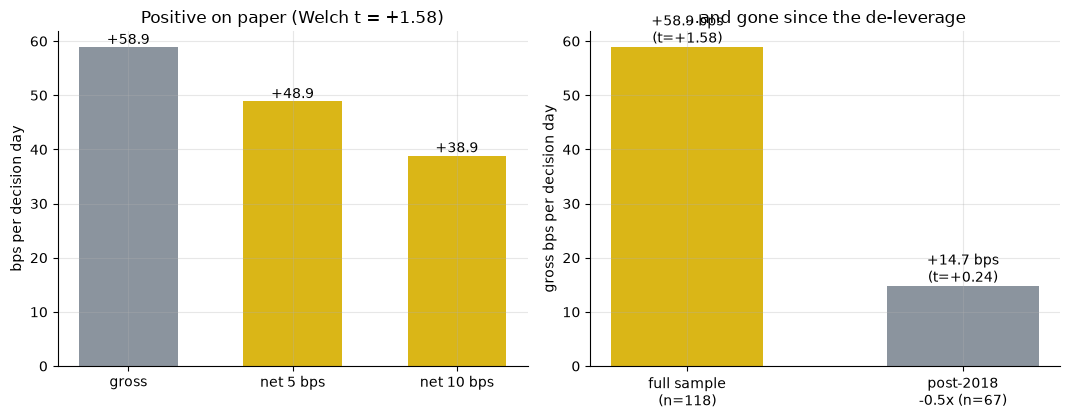

gross +58.9 -> net +48.9 / +38.9 bps  (t=+1.58);  post-2018 +14.7 bps (t=+0.24);  worst day -10.5%


In [6]:
if HAVE_REAL:
    rows = [st.svxy_capture(SVXY, FOMC, cost_bps=cb) for cb in (5.0, 10.0)]
    sv2 = st.svxy_capture(SVXY, FOMC, cost_bps=5.0, start=data.SVXY_DELEV)
    g = rows[0]['gross_bps']; n5, n10 = rows[0]['net_bps'], rows[1]['net_bps']
    tv, g2, t2 = rows[0]['welch_t'], sv2['gross_bps'], sv2['welch_t']
    worst = rows[0]['worst_day_pct']
else:
    g, n5, n10 = R['sv_gross'], R['sv_net5'], R['sv_net10']
    tv, g2, t2, worst = R['sv_t'], R['sv_post_gross'], R['sv_post_t'], R['sv_worst']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.8, 4.3))
a1.bar(['gross','net 5 bps','net 10 bps'], [g, n5, n10], color=[GREY, AMBER, AMBER], width=.6)
for i,v in enumerate([g, n5, n10]): a1.annotate(f'{v:+.1f}',(i,v),ha='center',va='bottom')
a1.set_ylabel('bps per decision day'); a1.set_title(f'Positive on paper (Welch t = {tv:+.2f})')
a2.bar(['full sample\n(n=118)','post-2018\n-0.5x (n=67)'], [g, g2], color=[AMBER, GREY], width=.55)
for i,(v,t_) in enumerate([(g,tv),(g2,t2)]):
    a2.annotate(f'{v:+.1f} bps\n(t={t_:+.2f})',(i,v),ha='center',va='bottom')
a2.set_ylabel('gross bps per decision day')
a2.set_title('...and gone since the de-leverage')
plt.tight_layout(); plt.show()
print(f'gross {g:+.1f} -> net {n5:+.1f} / {n10:+.1f} bps  (t={tv:+.2f});  '
      f'post-2018 {g2:+.1f} bps (t={t2:+.2f});  worst day {worst:+.1f}%')

> 💡 In plain words: +49 bps net per event, ~+3.9%/yr from eight afternoons — *if* you believe a t of 1.58. We don't (the bar is 2), and the post-de-leverage slice (+15 bps, t = 0.24) says the modern edge is ≈ 0. Structurally: SVXY holds VIX **futures**, whose basis prices the scheduled crush *before* the day — the holder collects only the surprise term. Add a -10.5% worst day and a product class that has already gapped to zero (XIV) — **H₄ not certified; Tradability = MIRAGE, third axis = MIXED**.

### 4f · Faithful-engine & power control — we know the truth here

Synthetic mean-reverting vol index, scheduled pseudo-decisions every 32nd business day, TUNABLE planted crush. The null (crush = 0) is checked over **20 seeds** — never a single stream.

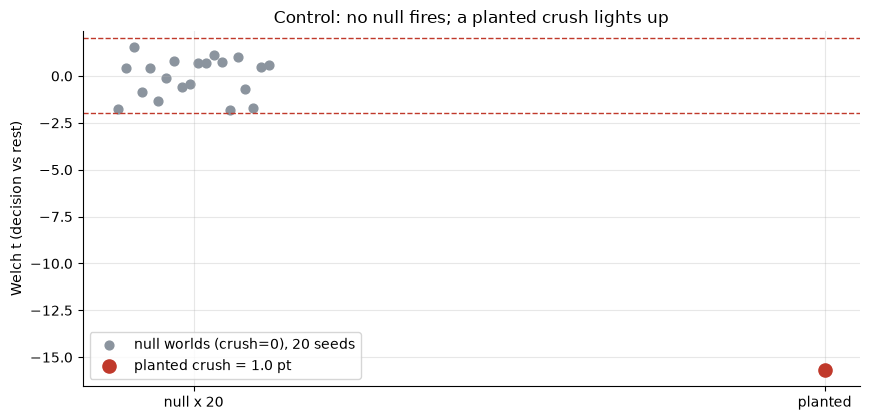

null: mean t = -0.04 (sd 1.04), |t|>=2 in 0/20 seeds  |  planted t = -15.67


In [7]:
null_ts = []
for s_ in range(20):
    close, dec = data.synthetic_world(crush=0.0, seed=637 + s_)
    null_ts.append(st.synthetic_detect(close, dec)['welch_t_pts'])
null_ts = np.asarray(null_ts)
close, dec = data.synthetic_world(crush=1.0, seed=637)
planted_t = st.synthetic_detect(close, dec)['welch_t_pts']
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.zeros(20) + np.linspace(-.12,.12,20), null_ts, color=GREY, s=40,
           label='null worlds (crush=0), 20 seeds')
ax.scatter([1], [planted_t], color=RED, s=90, zorder=5,
           label='planted crush = 1.0 pt')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.set_xticks([0, 1]); ax.set_xticklabels(['null x 20', 'planted'])
ax.set_ylabel('Welch t (decision vs rest)')
ax.set_title('Control: no null fires; a planted crush lights up')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: mean t = {null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(abs(null_ts)>=2).sum()}/20 seeds  |  planted t = {planted_t:+.2f}')

> 💡 In plain words: across 20 null worlds the detector averages t = -0.04 (sd 1.04) and **never** crosses the bar; a planted 1-point crush reads t = -15.67. The machinery is unbiased — the real-tape t ≈ −3.9 is the genuine article. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `REAL`** — decision-day ΔVIX **-0.415 pts (-1.97%)** vs +0.014: Welch t = **-3.51 / -3.94** (pts/log), NW t = **-3.47**, hit 65.9% (Wilson [60.0%, 71.4%]), placebo p = 0.00005; the crush *sticks* (day +1 t = +0.10) and lands on realized-loud days (range t = +4.04). Caveat named: post-2011 slice alone t = -1.21; decay uncertified (diff t = +1.15).
- **Tradability `MIRAGE`** — spot ^VIX untradable; the SVXY echo is +49 bps net/event at t = 1.58 (full) and +15 bps at t = 0.24 (post-2018), with a -10.5% worst day and gap-to-zero class risk (XIV). Futures pre-price the event; what's left is the surprise, i.e. a coin flip.
- **Retail capture? `MIXED`** — direction right, magnitude positive in sample, certification failed, modern edge ≈ 0, tails fat. Not *wrong* — just not *bankable*.

## 6 · Going further

- **The general object is the announcement premium.** Amengual-Xiu (2018) show downward vol jumps cluster on FOMC afternoons; Fernandez-Perez et al. (2017) time the intraday drop. The same physics runs CPI mornings, ECB Thursdays and earnings — the professional expressions live in event straddles and the futures basis, not in ETPs.
- **Why the futures leak the edge:** the VIX futures basis into a meeting *is* the market's estimate of the crush; holding SVXY through the event collects only the realization-minus-expectation residual. Measuring that basis directly (VX term structure around meetings) is the natural sequel study.
- **Dedup map:** [517-pre-fomc-drift](../../517-pre-fomc-drift/) (equity returns *before*), [67-fed-drift](../../67-fed-drift/) (its decay), [135-fomc-cycle](../../135-fomc-cycle/) (week parity), [322-fomc-blackout](../../322-fomc-blackout/) (the pre-meeting window), [605-vix-settlement-day](../../605-vix-settlement-day/) (settlement mornings, which *controls out* FOMC days — here promoted from confounder to subject).

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*